# Task 6: Diffusion Posterior Sampling (DPS) for solving linear inverse problems
### *EE 367, Stanford University*

In this task, you will implement Diffusion Posterior Sampling (DPS) by Chung et al. (2023) using a pre-trained DDPM to solve inverse problems like image inpainting and deconvolution. DPS leverages the posterior sampling interpretation of the diffusion model to solve inverse problems. It normalizes likelihood gradients during the reverse diffusion process to ensure stable sampling. Although in this assignment we use DPS to solve linear inverse problems, DPS can handle general inverse problems including nonlinear, whereas Score ALD cannot.

Your tasks:

- Implement DPS conditioning with normalized gradient updates
- Modify the sampling loop to incorporate DPS steps
- Test the method with:
  - Different scale parameters (0.1-1.0 range)
  - Different inverse problems (inpainting, deconvolution)
  - Various measurement conditions (mask patterns, blur levels)
  - Compare results with Score ALD

*Note:* Some helper functions are provided for you. Focus on implementing
the marked sections.

Refer to the paper for more information about DPS method:

H. Chung, J. Kim, M. T. Mccann, M. L. Klasky, and J. C. Ye, “Diffusion posterior sampling for general noisy inverse problems,” in *The Eleventh
International Conference on Learning Representations*, 2023.

Before you begin:
1. Download the folder `diffusion_project`
2. Upload the folder to your Google Drive
3. Change runtime type to "T4 GPU" (click the drop-down button in the top right corner of this page for "Additional connection options" then click "change runtime type", change to "T4 GPU" and save)

## Connect to your Google Drive to access `diffusion_project` and setup model environment

This section handles the necessary setup steps to run diffusion models in Google Colab:
1. Connects to Google Drive to access project files
2. Imports required libraries
3. Loads the pretrained diffusion model and supporting components

The model is pretrained on FFHQ-256 dataset.

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/My Drive/diffusion_project" # Replace with your path to the diffusion_project folder
os.chdir(path)
print(f"Current working directory: {os.getcwd()}")

# Import required packages
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from functools import partial

from guided_diffusion.unet import create_model
from guided_diffusion.gaussian_diffusion import get_named_beta_schedule
from util.img_utils import clear_color
from util.logger import get_logger
from util.img_utils import Blurkernel

from PIL import Image
import numpy as np
from tqdm.auto import tqdm

from skimage.metrics import peak_signal_noise_ratio as psnr
from util.setup_env import setup_diffusion_environment

# Initialize the diffusion environment
setup = setup_diffusion_environment()

# Extract components
model = setup['model']
device = setup['device']
logger = setup['logger']


Mounted at /content/drive
Current working directory: /content/drive/My Drive/diffusion_project


2026-03-13 22:55:30,809 [DPS] >> Device set to cuda:0.
INFO:DPS:Device set to cuda:0.


## Initialize DDPM parameters
Initialize the key parameters needed for the diffusion process. These parameters control how noise is added and removed during the diffusion steps.

In [2]:
num_timesteps = 1000 # Total number of noise steps
betas = get_named_beta_schedule(schedule_name="linear", num_diffusion_timesteps=num_timesteps)

alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas, axis=0)
alphas_cumprod_prev = np.append(1.0, alphas_cumprod[:-1])

sqrt_recip_alphas_cumprod = np.sqrt(1.0 / alphas_cumprod)
sqrt_recipm1_alphas_cumprod = (1.0 - alphas_cumprod) / np.sqrt(alphas_cumprod)

posterior_mean_coef1 = betas * np.sqrt(alphas_cumprod_prev) / (1.0-alphas_cumprod)
posterior_mean_coef2 = (1.0 - alphas_cumprod_prev) * np.sqrt(alphas) / (1.0 - alphas_cumprod)

posterior_variance = (
    betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
)
posterior_log_variance_clipped = np.log(
    np.append(posterior_variance[1], posterior_variance[1:])
)

## Define helper functions

This section defines utility functions needed for the diffusion process. Make use of the helper functions in your implementation.

In [3]:
def extract_and_expand(array, time, target):
    """
    Extract values from an array at specified timesteps and expand to match target shape.

    Args:
        array: Source array containing coefficient values
        time: Timestep indices to extract
        target: Tensor whose shape we want to match

    Returns:
        Expanded tensor matching target shape with values from array at specified times
    """
    array = torch.from_numpy(array).to(target.device)[time].float()
    while array.ndim < target.ndim:
        array = array.unsqueeze(-1)
    return array.expand_as(target)

def get_variance(x, t):
    """
    Calculate the variance of the posterior distribution at timestep t.

    Args:
        x: Input tensor containing model's variance predictions
        t: Current timestep indices

    Returns:
        Log variance interpolated between min and max values based on model prediction
    """
    model_var_values = x
    min_log = posterior_log_variance_clipped
    max_log = np.log(betas)

    # Extract and expand variance bounds
    min_log = extract_and_expand(min_log, t, x)
    max_log = extract_and_expand(max_log, t, x)

    # Interpolate between min and max variance (model_var_values is in [-1, 1])
    frac = (model_var_values + 1.0) / 2.0
    model_log_variance = frac * max_log + (1-frac) * min_log
    return model_log_variance

def process_xstart(x):
    """
    Clamp predicted x_0 values to valid range.

    Args:
        x: Input tensor to be processed

    Returns:
        Tensor with values clamped to [-1, 1] range
    """
    x = x.clamp(-1, 1)
    return x

## Define one step of sampling (i.e. calculate $\hat{x_0}$ and $x_{t-1}$)

This section implements the core sampling functions for the reverse diffusion process.
It contains three main components:

1. Single-step denoising (`denoise`): Predicts x_0 from noisy x_t
2. Posterior mean calculation (`q_posterior_mean`): Computes q(x_{t-1} | x_t, x_0)
3. Sampling step (`p_sample`): Performs one complete step of the reverse diffusion

These functions work together to gradually transform random noise into meaningful images. The functions are the same as the ones in previous tasks, so you can copy and paste the functions you implemented before.

In [4]:
def denoise(x_t, t, eps):
    """
    Perform single-step denoising using the predicted noise.
    i.e. x_0_hat from the DPS paper

    Args:
        x_t: Noisy image at timestep t
        t: Current timestep
        eps: Predicted noise from the model

    Returns:
        Denoised image prediction using the diffusion model equation
    """

    ac = extract_and_expand(alphas_cumprod, t, x_t)
    x0_hat = (x_t - torch.sqrt(1 - ac) * eps) / torch.sqrt(ac)
    return x0_hat

def q_posterior_mean(x_start, x_t, t):
    """
    Compute the mean of the diffusion posterior: q(x_{t-1} | x_t, x_0)

    Args:
        x_start: Predicted clean image (x_0)
        x_t: Current noisy image
        t: Current timestep

    Returns:
        Mean of the posterior distribution
    """
    assert x_start.shape == x_t.shape

    alpha_t = extract_and_expand(alphas, t, x_t)
    abar_t = extract_and_expand(alphas_cumprod, t, x_t)
    abar_tm1 = extract_and_expand(alphas_cumprod_prev, t, x_t)

    posterior_mean_coef1 = torch.sqrt(abar_tm1) * (1.0 - alpha_t) / (1.0 - abar_t)
    posterior_mean_coef2 = torch.sqrt(alpha_t) * (1.0 - abar_tm1) / (1.0 - abar_t)

    return posterior_mean_coef1 * x_start + posterior_mean_coef2 * x_t

def p_sample(model, x, t):
    """
    Perform one complete step of the sampling process.

    Args:
        model: The DDPM model
        x: Current noisy image
        t: Current timestep

    Returns:
        Dictionary containing:
        - sample: Next image in sequence (x_{t-1})
        - pred_xstart: Predicted clean image (x_0)
    """
    model_output = model(x, t)

    # Split into noise and variance predictions
    model_output, model_var_values = torch.split(model_output, x.shape[1], dim=1)

    # Predict x_0 and prepare for next step
    x_0_hat = process_xstart(denoise(x, t, model_output))
    x_t = q_posterior_mean(x_0_hat, x, t)

    # Add sampling noise scaled by predicted variance (except at t=0)
    noise = torch.randn_like(x)
    model_log_variance = get_variance(model_var_values, t)

    if t[0] != 0:  # no noise when t == 0
        x_t += torch.exp(0.5 * model_log_variance) * noise

    return {'sample': x_t, 'pred_xstart': x_0_hat}

## Prepare measurement process

This section defines the forward measurement process:
1. Incorporate measurement noise
2. Mask generation for inpainting (box or random)
3. Forward operations for different editing tasks (inpainting or deconvolution)

In [5]:
sigma = 0.05 # Define noise parameter for measurement
def noiser(data):
    """
    Add Gaussian noise to input data for measurement robustness.

    Args:
        data: Input tensor to be noised

    Returns:
        Noised tensor with added Gaussian noise (sigma)
    """
    return data + torch.randn_like(data, device=data.device) * sigma

def mask_gen(data, mask_type):
    """
    Generate masks for image inpainting tasks.

    Args:
        data: Input image tensor of shape [1, 3, 256, 256]
        mask_type: Type of mask ('box' or 'random')

    Returns:
        Binary mask tensor where 0 indicates masked regions

    Supports:
    - 'box': Creates a 50x50 rectangular mask
    - 'random': Randomly masks 50% of pixels
    """
    mask = torch.ones_like(data) # torch.Size([1, 3, 256, 256])
    if mask_type=='box':
        box_x, box_y, box_w, box_h = 150, 100, 50, 50  # Define box coordinates and size
        mask[:, :, box_y:box_y+box_h, box_x:box_x+box_w] = 0.
    elif mask_type=='random':
        percentage_to_mask = 0.5  # Mask 50% of the image
        total_pixels = data.size(2) * data.size(3)
        num_pixels_to_mask = int(percentage_to_mask * total_pixels)
        mask_indices = np.random.choice(total_pixels, size=num_pixels_to_mask, replace=False)
        mask[:, :, mask_indices // data.size(3), mask_indices % data.size(3)] = 0
    return mask

def forward(data, task, mask_type):
    """
    Apply forward measurement operation based on specified task.

    Args:
        data: Input image tensor
        task: Type of editing task ('inpaint' or 'deconv')
        mask_type: Type of mask for inpainting

    Returns:
        Processed image according to task:
        - Inpainting: Masked image
        - Deconvolution: Blurred image

    Note: For deconvolution, uses Gaussian blur with kernel_size=61, std=3.0
    """
    if task=='inpaint':
      mask = mask_gen(data, mask_type)
      return data * mask.to(device)

    elif task=='deconv':
      conv = Blurkernel(blur_type='gaussian',
                        kernel_size=61,
                        std=3.0,
                        device=device).to(device)
      return conv(data)

## Implement likelihood constraint
This section implements likelihood gradient based on measurements and DPS conditioning using normalized likelihood gradients.

`grad_likelihood()` function is the same as the one you implemented in task 4.

Make sure to adjust the `scale` factor as recommended for different tasks.

In [6]:
def grad_likelihood(x_prev, x_0_hat, measurement, task, mask_type):
    """
    Computes gradient of negative log-likelihood with respect to x_prev

    Args:
        x_prev: Current denoised estimate (requires grad)
        x_0_hat: Predicted clean image
        measurement: Original corrupted measurement
        task: Type of inverse problem ('inpaint' or 'deconv')
        mask_type: For inpainting, specifies mask pattern ('box' or 'random')

    Returns:
        grad: Gradient of neg log likelihood wrt x_prev
    """

    x_prev = x_prev.requires_grad_(True)

    pred_meas = forward(x_0_hat, task, mask_type)
    loss = 0.5 * torch.sum((pred_meas - measurement) ** 2)

    grad = torch.autograd.grad(loss, x_prev, retain_graph=True, allow_unused=True)[0]
    return grad



def dps_conditioning(x_prev, x_t, x_0_hat, measurement, task, mask_type):
    """
    Applies DPS conditioning using normalized likelihood gradients
    Gradient is normalized by its L2 norm for stable updates

    Args:
        x_prev: Current denoised estimate (requires grad)
        x_t: Current noisy estimate to be updated
        x_0_hat: Predicted clean image
        measurement: Original corrupted measurement
        task: Type of inverse problem ('inpaint' or 'deconv')
        mask_type: For inpainting, specifies mask pattern ('box' or 'random')

    Returns:
        x_t: Updated estimate after DPS conditioning
    """

    scale = 0.3 # tuning parameter (recommended: 1.0 for box, 0.1 for random, 0.3 for deconv, choose in the range [0.1, 1.0])

    ############### begin: complete the following code section  ###############
    grad = grad_likelihood(x_prev, x_0_hat, measurement, task, mask_type)
    norm_factor = scale / torch.norm(grad)
    x_t = x_t - norm_factor * grad

    ############### end: complete the following code section  ###############

    return x_t

## Implement sampling loop for DPS

This section implements the specialized sampling loop for DPS. It also includes optional progress visualization.

In [7]:
def dps(model, x_start, measurement, measurement_cond_fn, task, mask_type, record, save_root):

    img = x_start
    pbar = tqdm(list(range(num_timesteps))[::-1])

    device = x_start.device

    for idx in pbar:
        time = torch.tensor([idx] * img.shape[0], device=device)

        img = img.requires_grad_()

        ############### begin: complete the following code section  ###############
        gen = p_sample(model, img, time)
        img = dps_conditioning(img, gen['sample'], gen['pred_xstart'], measurement, task, mask_type)



        ############### end: complete the following code section  ###############

        img = img.detach_()

        if record:
            if idx % 10 == 0:
                file_path = os.path.join(save_root, f"progress/x_{str(idx).zfill(4)}.png")
                plt.imsave(file_path, clear_color(img))

    return img

## Inference

This section demonstrates the complete DPS pipeline, from loading an input image
through measurement simulation to final edited result generation.

Choose appropriate settings for each option below by clicking the drop-down menu. Note that when you want to test for deconv, setting for mask_type does not matter.

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


2026-03-13 23:02:08,326 [DPS] >> Inference for image
INFO:DPS:Inference for image


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

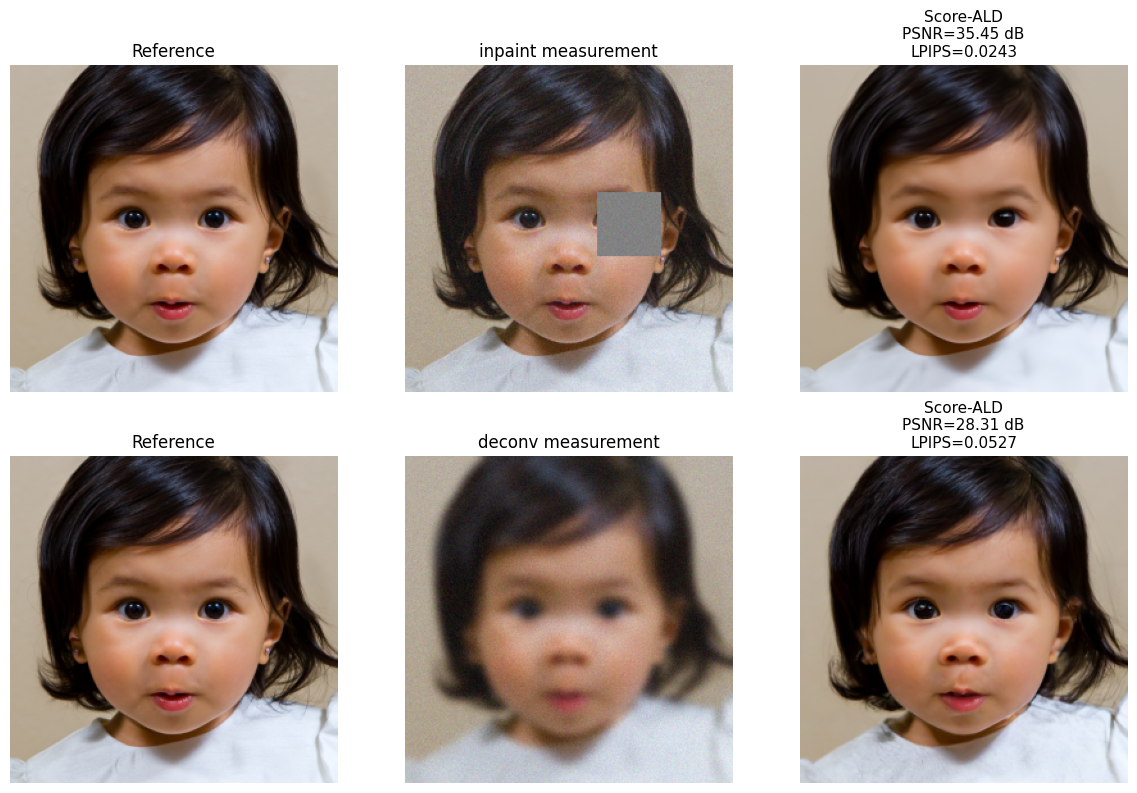

In [9]:
import os
import lpips
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as psnr

loss_fn = lpips.LPIPS(net='alex').to(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

out_path = "results/"
os.makedirs(out_path, exist_ok=True)

fname = '00003.png'
img = Image.open(f'data/samples/{fname}').convert('RGB')
img = transform(img)

logger.info("Inference for image")
ref_img = img.to(device).unsqueeze(dim=0)

tasks = ['inpaint', 'deconv']
mask_type = 'box'
num_steps = 999   # full reverse chain if valid timesteps are 0..999

results = []

fig, axes = plt.subplots(len(tasks), 3, figsize=(12, 8))
if len(tasks) == 1:
    axes = axes[None, :]

for row, task in enumerate(tasks):
    y = forward(ref_img, task, mask_type)
    y_n = noiser(y)

    x_start = torch.randn(ref_img.shape, device=device).requires_grad_()

    sample = dps(
        model,
        x_start,
        measurement=y_n,
        measurement_cond_fn=dps_conditioning,
        task=task,
        mask_type=mask_type,
        record=False,
        save_root=out_path
    )

    ref_np = ref_img[0].permute(1, 2, 0).detach().cpu().numpy()
    sample_np = sample[0].permute(1, 2, 0).detach().cpu().numpy()

    psnr_value = psnr(ref_np, sample_np, data_range=2.0)
    lpips_value = loss_fn(ref_img, sample).item()

    results.append({
        "task": task,
        "num_steps": num_steps,
        "psnr": psnr_value,
        "lpips": lpips_value,
    })

    axes[row, 0].imshow(clear_color(ref_img[0]))
    axes[row, 0].set_title("Reference", fontsize=12)
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(task.capitalize(), fontsize=14)

    axes[row, 1].imshow(clear_color(y_n[0]))
    axes[row, 1].set_title(f"{task} measurement", fontsize=12)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(clear_color(sample[0]))
    axes[row, 2].set_title(
        f"Score-ALD\nPSNR={psnr_value:.2f} dB\nLPIPS={lpips_value:.4f}",
        fontsize=11
    )
    axes[row, 2].axis("off")

    stem = fname.rsplit('.', 1)[0]
    plt.imsave(
        os.path.join(out_path, f"{task}_measurement_{stem}.png"),
        clear_color(y_n[0])
    )
    plt.imsave(
        os.path.join(out_path, f"{task}_scoreald_{stem}.png"),
        clear_color(sample[0])
    )

plt.tight_layout()
fig.savefig(
    os.path.join(out_path, f"scoreald_comparison_{stem}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


## Show results

Visualize the input, ground truth, and result images.

In [ ]:
plt.imsave(out_path + f'input_{task}_dps_{fname}', clear_color(y_n))
plt.imsave(out_path + f'label_{task}_dps_{fname}', clear_color(ref_img))
plt.imsave(out_path + f'recon_{task}_dps_{fname}', clear_color(sample))

images = [clear_color(y_n), clear_color(ref_img), clear_color(sample)]
titles = ["Input", "Ground Truth", "Generated using DPS"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(titles[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

## Evaluate the result

This section calculates standard image quality metrics to evaluate DPS performance:
1. PSNR (Peak Signal-to-Noise Ratio): Measures noise level/reconstruction quality (higher the better)
  *   *your result should be approx. 28 or above*
2. LPIPS (Learned Perceptual Image Patch Similarity): Measures perceptual similarity (lower the better)
  *   *your result should be approx. 0.05 or below*


In [ ]:
import lpips
ref_img_np = ref_img.squeeze(0).permute(1, 2, 0).cpu().numpy()
sample_np = sample.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()

# Calculate PSNR & LPIPS
psnr_value = psnr(ref_img_np, sample_np, data_range=ref_img_np.max() - ref_img_np.min())
loss_fn = lpips.LPIPS(net='alex').to(device)
lpips_value = loss_fn.forward(ref_img, sample)

print("PSNR:", psnr_value)
print("LPIPS:", lpips_value.item())